In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [25]:
iris = load_iris()

In [26]:
X = iris.data
y = iris.target

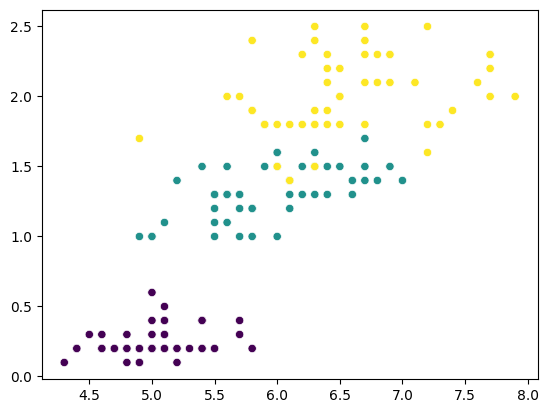

In [35]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,3], c=y)
plt.show()

In [34]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
# optional - dimensionality reduction using PCA
from sklearn.decomposition import PCA
pca = PCA(
    n_components=2,
)
pca_data = pca.fit_transform(X_scaled)


In [53]:
# elbow method for optimal K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

wcss

c:\Users\srija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\srija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\srija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\srija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[574.8792432000106,
 197.4038160454129,
 115.18647050742705,
 89.97446142147335,
 67.09565305826138,
 59.39164837954529,
 49.343102253366226,
 42.01559516050172,
 36.2958319010529,
 30.50197892140271]

<Axes: >

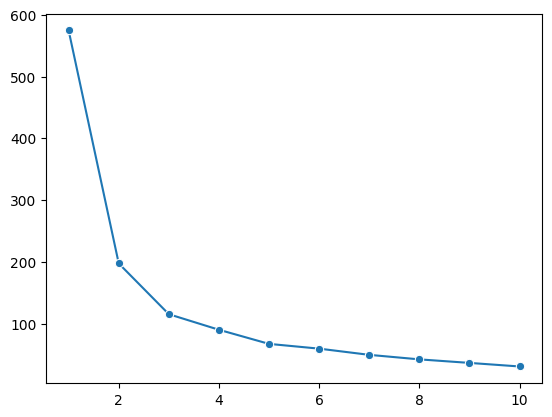

In [54]:
sns.lineplot(x=range(1, 11), y=wcss, marker='o')

c:\Users\srija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

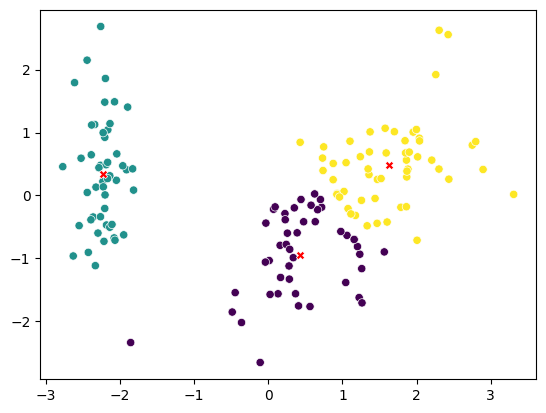

In [61]:
# APPLY K MEANS ALGO

kmeans = KMeans(
    n_clusters=3
)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="X", c='red')

<Axes: >

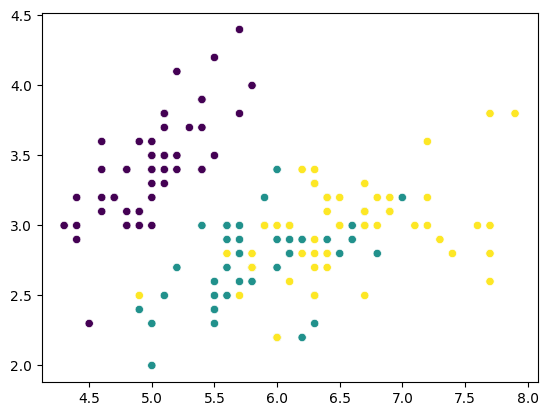

In [58]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=y)